# Community Detection

### Import libraries

In [4]:
import math
import numpy as np
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns
import time
import dimod
from networkx.algorithms.community.quality import modularity as nx_modularity
from dwave.system import LeapHybridSampler
from dwave.system import DWaveSampler, EmbeddingComposite
from dwave.system import FixedEmbeddingComposite
from dwave.system import LeapHybridDQMSampler
from dwave.samplers import SimulatedAnnealingSampler
from dwave.embedding import embed_bqm
from dwave.embedding.chain_strength import uniform_torque_compensation
from minorminer import find_embedding
from dimod import ExactSolver
from dimod import ConstrainedQuadraticModel, Binary, quicksum
from dwave.system import LeapHybridCQMSampler
from sklearn.metrics import normalized_mutual_info_score

# To extract, save, and reuse embedding
import json
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

### Load data

In [29]:
# Load preprocessed network
G = nx.read_graphml('neuronal_graphs/plane2_neurons15.graphml')
G.remove_nodes_from(list(nx.isolates(G)))

print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Graph type: {type(G)}")
print(f"Is directed: {G.is_directed()}")

# Display sample node and edge attributes
sample_node = list(G.nodes())[0]
sample_edge = list(G.edges(data=True))[0]
print(f"\nSample node: {sample_node}")
print(f"Sample edge: {sample_edge}")

Graph loaded: 42 nodes, 46 edges
Graph type: <class 'networkx.classes.digraph.DiGraph'>
Is directed: True

Sample node: 5
Sample edge: ('5', '43', {'weight': -0.469197495992412})


# 1 Graph preprocessing

### 1.1 Conversion to adjacency matrix

In [30]:
# Convert directed graph to undirected
G_undirected = G.to_undirected()

# Remove any remaining self-loops
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

# Create unweighted adjacency matrix
A = nx.adjacency_matrix(G_undirected, weight=None).toarray()
N = G_undirected.number_of_nodes()
M = G_undirected.number_of_edges()  # Total number of edges

print(f"\nUndirected graph: {N} nodes, {M} edges")
print(f"Adjacency matrix shape: {A.shape}")
print(f"Sparsity: {(A == 0).sum() / A.size * 100:.2f}% zeros")
print(f"\nDegree statistics:")
degrees = [G_undirected.degree(n) for n in G_undirected.nodes()]
print(f"  Min: {min(degrees)}, Max: {max(degrees)}, Mean: {np.mean(degrees):.2f}")


Undirected graph: 42 nodes, 23 edges
Adjacency matrix shape: (42, 42)
Sparsity: 97.39% zeros

Degree statistics:
  Min: 1, Max: 2, Mean: 1.10


In [31]:
def communities_to_partition(communities):
    """
    Convert a list of community sets to a partition array.
    Returns: array where partition[i] = community_id for node i
    """
    node_list = list(G_undirected.nodes())  # Use the current graph's node order
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}
    partition = np.zeros(len(node_list), dtype=int)
    for community_id, community_set in enumerate(communities):
        for node in community_set:
            partition[node_to_idx[node]] = community_id
    return partition

def compute_modularity(partition, A):
    """
    Compute modularity Q for a given partition.
    Q = (1/2m) * sum_ij (A_ij - k_i*k_j/2m) * delta(c_i, c_j)
    where k_i is the degree of node i, and delta(c_i, c_j) = 1 if nodes i,j in same community
    """
    n = A.shape[0]

    degrees = A.sum(axis=1)
    m = A.sum() / 2.0  # total edges (double counted in adjacency matrix)
    
    Q = 0.0
    for i in range(n):
        for j in range(n):
            if partition[i] == partition[j]:
                Q += A[i, j] - (degrees[i] * degrees[j]) / (2.0 * m)
    
    Q /= (2.0 * m)
    return Q

def compute_conductance(partition, A):
    degrees = A.sum(axis=1)
    conductances = []
    for community_id in np.unique(partition):
        S  = np.where(partition == community_id)[0]
        if len(S) <= 1:
            continue
        Sc = np.where(partition != community_id)[0]
        if len(Sc) == 0:
            continue
        cut   = A[np.ix_(S, Sc)].sum()
        vol_S = degrees[S].sum()
        vol_c = degrees[Sc].sum()
        denom = min(vol_S, vol_c)
        if denom > 0:
            conductances.append(cut / denom)
    singleton_count = 0
    double_count = 0
    for community_id in np.unique(partition):
        S = np.where(partition == community_id)[0]
        if len(S) == 1:
            singleton_count += 1  # Max conductance for single-node communities
        if len(S) == 2:
            double_count += 1  # Max conductance for two-node communities
            
    penalty = (singleton_count/(len(partition)))+(double_count/(len(partition)*2))
    return (np.mean(conductances) + (1-np.mean(conductances))*penalty) if conductances else np.nan


# 2 Classical community detection

In [32]:
def greedy_refinement(A, partition):
    """
    Refines the partition using a greedy local search.
    Moves each node to the community that gives the highest modularity increase.
    """
    refined_partition = partition.copy()
    N = A.shape[0]
    unique_communities = np.unique(partition)
    improved = True
    
    current_modularity = compute_modularity(refined_partition, A)
    
    print(f"Starting refinement... Initial Modularity: {current_modularity:.6f}")
    
    while improved:
        improved = False
        nodes = np.random.permutation(N)
        
        for i in nodes:
            best_move = refined_partition[i]
            initial_comm = refined_partition[i]
            for target_comm in unique_communities:
                if target_comm == initial_comm:
                    continue
                refined_partition[i] = target_comm
                new_modularity = compute_modularity(refined_partition, A)
                if new_modularity > current_modularity:
                    current_modularity = new_modularity
                    best_move = target_comm
                    improved = True
            refined_partition[i] = best_move
            
    print(f"Refinement complete. Optimized Modularity: {current_modularity:.6f}")
    return refined_partition

### 2.1 Louvain

Tuning resolution parameter for Louvain

  Max Modularity: 0.477316
  Number of Communities: 30
  Conductance: 0.600000


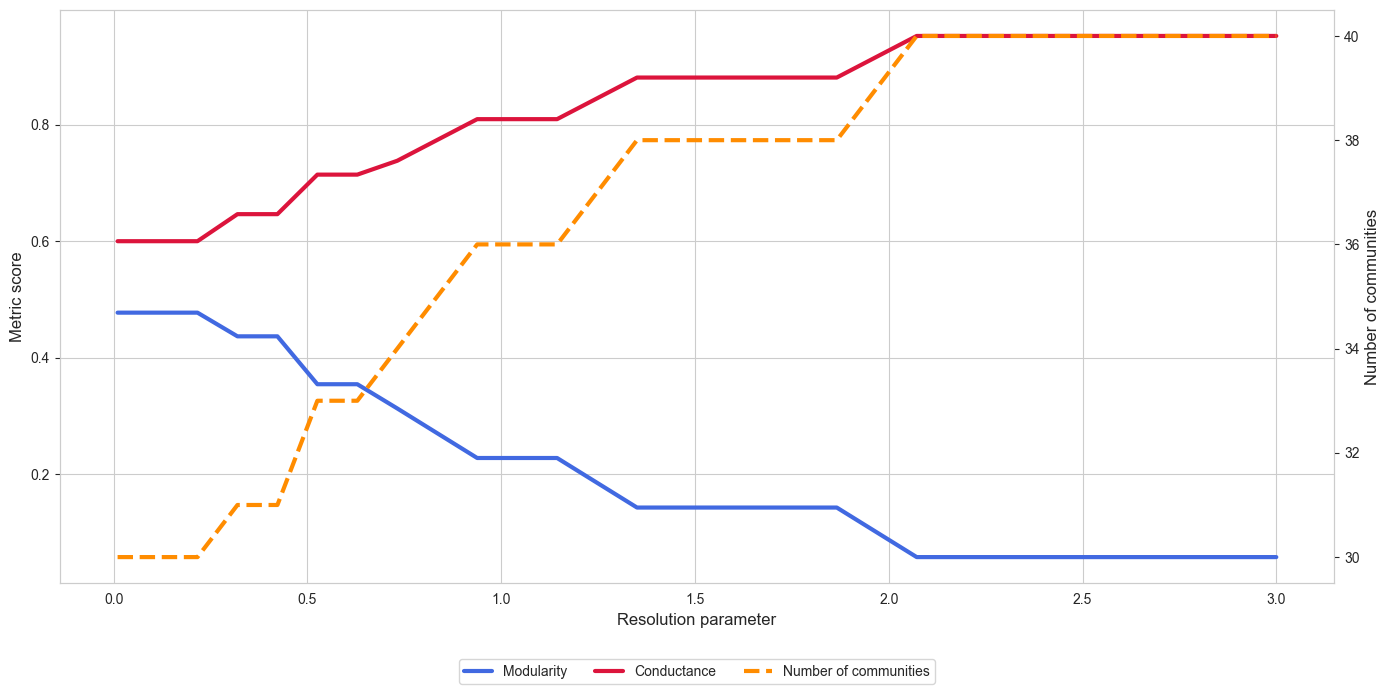

In [33]:
resolution_range = np.linspace(0.01, 3.0, 30)
tuning_results = []
for res in resolution_range:
    start_time = time.time()
    # run Louvain with specified resolution
    communities_louvain = list(nx.community.louvain_communities(G_undirected, seed=42, resolution=res))
    runtime = time.time() - start_time
    
    # calculate/post process
    partition_louvain = communities_to_partition(communities_louvain)
    modularity_louvain = compute_modularity(partition_louvain, A)
    conductance_louvain = compute_conductance(partition_louvain, A)
    
    tuning_results.append({
        'resolution': res,
        'num_communities': len(communities_louvain),
        'modularity': modularity_louvain,
        'conductance': conductance_louvain,
        'runtime': runtime
    })

df_tuning = pd.DataFrame(tuning_results)

best_mod_row = df_tuning.loc[df_tuning['modularity'].idxmax()]

print(f"  Max Modularity: {best_mod_row['modularity']:.6f}")
print(f"  Number of Communities: {int(best_mod_row['num_communities'])}")
print(f"  Conductance: {best_mod_row['conductance']:.6f}")

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(data=df_tuning, x='resolution', y='modularity', ax=ax1, label='Modularity', color='royalblue',linewidth=3)
sns.lineplot(data=df_tuning, x='resolution', y='conductance', ax=ax1, label='Conductance', color='crimson', linewidth=3)
ax1.set_ylabel('Metric score', fontsize=12)
ax1.set_xlabel('Resolution parameter', fontsize=12)

ax2 = ax1.twinx()
sns.lineplot(data=df_tuning, x='resolution', y='num_communities', ax=ax2, label='Number of communities', color='darkorange', linestyle='--', linewidth=3)
ax2.set_ylabel('Number of communities', fontsize=12)
ax2.grid(False) 

# sync legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)

plt.tight_layout()
plt.show()

In [34]:
start_time = time.time()
communities_louvain = list(nx.community.louvain_communities(G_undirected, seed=42))
louvain_runtime = time.time() - start_time

partition_louvain = communities_to_partition(communities_louvain)
partition_louvain_optimized = greedy_refinement(A, partition_louvain)
modularity_louvain = compute_modularity(partition_louvain_optimized, A)
conductance_louvain = compute_conductance(partition_louvain_optimized, A)

print(f"Runtime: {louvain_runtime:.4f}s")
print(f"Number of communities: {len(communities_louvain)}")
print(f"Modularity: {modularity_louvain:.6f}")
print(f"Conductance: {conductance_louvain:.6f}")
print(f"Community sizes: {sorted([len(c) for c in communities_louvain], reverse=True)}")
print(f"Number of communities: {len(communities_louvain)}")

Starting refinement... Initial Modularity: 0.227788
Refinement complete. Optimized Modularity: 0.941399
Runtime: 0.0014s
Number of communities: 36
Modularity: 0.941399
Conductance: 0.178571
Community sizes: [2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Number of communities: 36


### 2.2 Greedy modularity optimization

In [35]:
start_time = time.time()
communities_greedy = list(nx.community.greedy_modularity_communities(G_undirected))
greedy_runtime = time.time() - start_time

#no need for optimization because it accomplishes the same (greedy)

partition_greedy = communities_to_partition(communities_greedy)
modularity_greedy = compute_modularity(partition_greedy, A)
conductance_greedy = compute_conductance(partition_greedy, A)

print(f"Runtime: {greedy_runtime:.4f}s")
print(f"Number of communities: {len(communities_greedy)}")
print(f"Modularity: {modularity_greedy:.6f}")
print(f"Conductance: {conductance_greedy:.6f}")
print(f"Community sizes: {sorted([len(c) for c in communities_greedy], reverse=True)}")

Runtime: 0.0008s
Number of communities: 19
Modularity: 0.941399
Conductance: 0.178571
Community sizes: [3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


### 2.3 Greedy w/ best_n

In [36]:
start_time = time.time()
communities_greedy_bestn = list(nx.community.greedy_modularity_communities(G_undirected, best_n=math.sqrt(N)))
greedy_bestn_runtime = time.time() - start_time

partition_greedy_bestn = communities_to_partition(communities_greedy_bestn)
modularity_greedy_bestn = compute_modularity(partition_greedy_bestn, A)
conductance_greedy_bestn = compute_conductance(partition_greedy_bestn, A)

print(f"Runtime: {greedy_bestn_runtime:.4f}s")
print(f"Number of communities: {len(communities_greedy_bestn)}")
print(f"Modularity: {modularity_greedy_bestn:.6f}")
print(f"Conductance: {conductance_greedy_bestn:.6f}")
print(f"Community sizes: {sorted([len(c) for c in communities_greedy_bestn], reverse=True)}")

Runtime: 0.0008s
Number of communities: 6
Modularity: 0.378072
Conductance: 0.059524
Community sizes: [32, 2, 2, 2, 2, 2]


# 3 QUBO with Modularity

### 3.0 Build QUBO matrix

In [ ]:
def build_modularity_qubo(A, num_communities=None, lambda_penalty=None, verbose=False):
    """
    Build QUBO matrix for modularity maximization via binary community assignment.
    Variables: x_{i,c} for i in nodes, c in communities
    Constraint: Each node assigned to exactly one community (handled via penalty)
    
    One-hot encoding:
    - num_binary_vars = N * num_communities
    - x[i*num_communities + c] = 1 if node i in community c
    
    QUBO objective: minimize -Q + lambda * penalty
    
    Parameters:
    -----------
    A : ndarray
        Adjacency matrix
    num_communities : int, optional
        Number of communities (default: sqrt(N))
    lambda_penalty : float, optional
        Penalty weight for one-hot constraint.
        If None, automatically set to 10x the max modularity contribution.
    verbose : bool
        Print diagnostics
    """

    if num_communities is None:
        num_communities = max(2, int(np.sqrt(N)))

    n_vars = N * num_communities 
    Q = {}

    degrees = A.sum(axis=1)
    m = A.sum() / 2  # Total edges

    # Modularity term: Q = (1/2m) * sum_{c} sum_{i,j} B_{ij} x_{i,c} x_{j,c}
    # For minimization, use -Q in QUBO objective
    max_B = 0  # Track max modularity contribution for scaling
    
    for c in range(num_communities):
        for i in range(N):
            for j in range(i, N):
                var_i = i * num_communities + c
                var_j = j * num_communities + c
                B_ij = A[i, j] - (degrees[i] * degrees[j]) / (2 * m)
                coeff = -B_ij / (2 * m)
                max_B = max(max_B, abs(coeff))

                if i == j:  # diagonal
                    if var_i not in Q:
                        Q[var_i] = 0.0
                    Q[var_i] += coeff
                else:  # off-diagonal
                    key = (var_i, var_j) if var_i < var_j else (var_j, var_i)
                    if key not in Q:
                        Q[key] = 0.0
                    Q[key] += coeff

    if lambda_penalty is None:
        lambda_penalty = max(10.0 * max_B, 5.0)  # At least 5.0
    
    if verbose:
        print(f"Modularity scale (max |coeff|): {max_B:.6f}")
        print(f"Penalty weight (lambda): {lambda_penalty:.6f}")

    # Constraint penalty: each node in exactly one community
    # Penalty: lambda * (sum_c x_{i,c} - 1)^2
    # Expansion:
    #   (sum_c x_{i,c} - 1)^2 = sum_c x_{i,c}^2 + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} - 2*sum_c x_{i,c} + 1
    #   = sum_c x_{i,c} + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} - 2*sum_c x_{i,c} + 1   [since x^2=x for binary]
    #   = -sum_c x_{i,c} + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} + 1
    
    # Linear coefficient: -lambda per variable
    # Quadratic coefficient: +2*lambda per pair

    const_term = N * lambda_penalty
    
    for i in range(N):
        # Linear terms: -lambda * x_{i,c}
        for c in range(num_communities):
            var_i = i * num_communities + c
            if var_i not in Q:
                Q[var_i] = 0.0
            Q[var_i] += -lambda_penalty

        # Quadratic terms: +2*lambda * x_{i,c1}*x_{i,c2}
        for c1 in range(num_communities):
            for c2 in range(c1 + 1, num_communities):
                var_1 = i * num_communities + c1
                var_2 = i * num_communities + c2
                key = (var_1, var_2) if var_1 < var_2 else (var_2, var_1)
                if key not in Q:
                    Q[key] = 0.0
                Q[key] += 2.0 * lambda_penalty

    Q['__const__'] = const_term
    
    if verbose:
        print(f"Constant term (N*lambda): {const_term:.2f}")
        print(f"Total QUBO terms: {len(Q)-1} + 1 const")  # -1 for const term itself

    return Q, num_communities

Eigengap estimate: k = 19 communities
Number of (near-)zero eigenvalues (connected components): 19


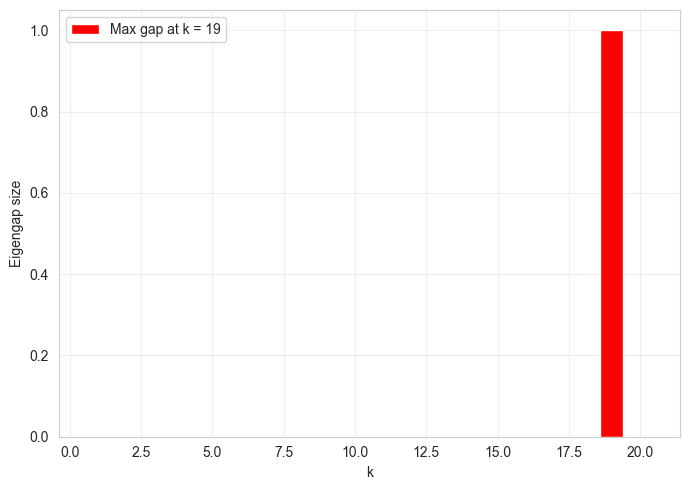

In [38]:
# compute the maximum eigengap to estimate number of communities

def compute_eigengap_estimate(A, max_k=20, plot=True):
    """
    Estimate the number of communities using the eigengap heuristic on the
    unnormalized graph Laplacian L = D - A.
    
    k_estimate: estimated number of communities 
    eigenvalues: full sorted array of eigenvalues
    gaps: array of consecutive eigenvalue differences
    """
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    L = D - A

    eigenvalues = np.linalg.eigvalsh(L)
    eigenvalues = np.sort(eigenvalues)
    eigenvalues[eigenvalues < 0] = 0

    # Only look for the gap within the first max_k eigenvalues (smallest ones)
    max_k = min(max_k, len(eigenvalues) - 1)
    eigenvalues_subset = eigenvalues[:max_k + 1]
    gaps = np.diff(eigenvalues_subset)
    k_estimate = int(np.argmax(gaps)) + 1
    k_estimate = max(2, k_estimate)  # at least 2 communities

    print(f"Eigengap estimate: k = {k_estimate} communities")

    # Number of (near-)zero eigenvalues = number of connected components
    num_zero_eigenvalues = int(np.sum(eigenvalues < 1e-8))
    print(f"Number of (near-)zero eigenvalues (connected components): {num_zero_eigenvalues}")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(range(1, max_k + 1), gaps, color='steelblue')
    ax.bar(k_estimate, gaps[k_estimate - 1], color='red', label=f'Max gap at k = {k_estimate}')
    ax.set_xlabel('k')
    ax.set_ylabel('Eigengap size')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return k_estimate, eigenvalues, gaps


k_eigengap, laplacian_eigenvalues, eigengaps = compute_eigengap_estimate(A, max_k=20, plot=True)

Eigengap estimate: k = 19 communities
Number of (near-)zero eigenvalues (connected components): 19


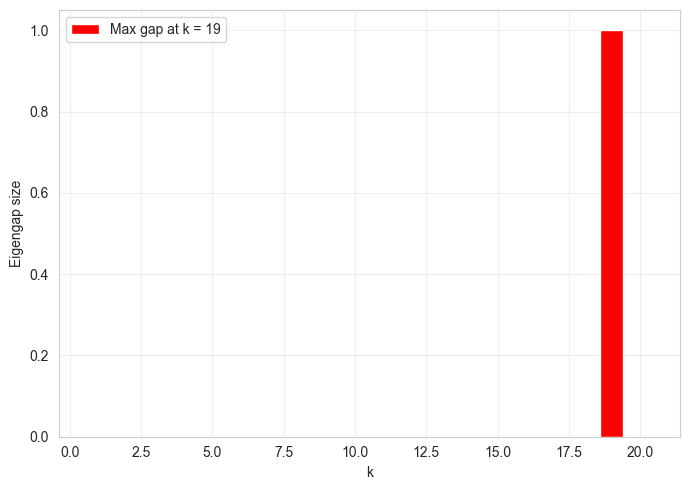

Target number of communities: 19
Total QUBO variables: 798

Building QUBO matrix...
Modularity scale (max |coeff|): 0.021267
Penalty weight (lambda): 5.000000
Constant term (N*lambda): 210.00
Total QUBO terms: 24339 + 1 const
QUBO built with 24339 terms
Constant term: 210.00


In [39]:
# Estimated using eigengap
num_communities_target, eigenvalues, gaps = compute_eigengap_estimate(A)
print(f"Target number of communities: {num_communities_target}")
print(f"Total QUBO variables: {N * num_communities_target}")

# Build QUBO
print(f"\nBuilding QUBO matrix...")
Q_dict, k_communities = build_modularity_qubo(A, num_communities_target, verbose=True)
print(f"QUBO built with {len(Q_dict)-1} terms")
print(f"Constant term: {Q_dict.get('__const__', 0):.2f}")

In [40]:
# Convert QUBO to BQM (Binary Quadratic Model) for D-Wave
Q_dict_clean = {}
const_offset = 0

for k, v in Q_dict.items():
    if k == '__const__':
        # Extract constant term for later addition
        const_offset = float(v)
    elif isinstance(k, tuple):
        Q_dict_clean[k] = float(v)
    else:
        node_idx = int(k)
        Q_dict_clean[(node_idx, node_idx)] = float(v)

# Create BQM and add the constant offset
bqm = dimod.BinaryQuadraticModel.from_qubo(Q_dict_clean)

# Add constant term to the BQM's offset
bqm.offset += const_offset

print(f"BQM created: {bqm.num_variables} variables, {len(bqm.quadratic)} interactions")
print(f"BQM offset (constant term): {bqm.offset:.2f}")

BQM created: 798 variables, 23541 interactions
BQM offset (constant term): 210.00


### 3.1 Classical solvers

Simulated annealing

In [19]:
start_time = time.time()
sa_sampler = SimulatedAnnealingSampler()
sampleset_sa = sa_sampler.sample(bqm, num_reads=100, seed=42)
sa_runtime = time.time() - start_time

best_sample_sa = sampleset_sa.first.sample
best_energy_sa = sampleset_sa.first.energy

print(f"Runtime: {sa_runtime:.4f}s")
print(f"Best energy: {best_energy_sa:.6f}")
print(f"Number of reads: 100")
print(f"Top 5 solutions:")

# Convert generator into list
top5 = list(sampleset_sa.data(['sample', 'energy', 'num_occurrences'], sorted_by='energy'))[:5]
for i, (sample, energy, num_occurrences) in enumerate(top5):
    print(f"  {i+1}. Energy: {energy:.6f}, Occurrences: {num_occurrences}")

/Users/carolineli/Documents/coding/senior_research/.venv/lib/python3.13/site-packages/dwave/samplers/sa/sampler.py:48: SyntaxWarning: invalid escape sequence '\ '
  :math:`\\beta`.\ [#]_ By default each spin is updated once in a fixed order per point
/Users/carolineli/Documents/coding/senior_research/.venv/lib/python3.13/site-packages/dwave/samplers/sa/sampler.py:177: SyntaxWarning: invalid escape sequence '\ '
  :math:`\\beta`\ [#]_ schedule. The schedule is


KeyboardInterrupt: 

In [20]:
def extract_communities_from_sample(sample, N, k_communities):
    """
    Extract community assignments from QUBO sample.
    For node i, find c where x_{i,c} = 1
    """
    partition = np.zeros(N, dtype=int)
    
    for i in range(N):
        # Find which community this node is assigned to
        for c in range(k_communities):
            var_idx = i * k_communities + c
            if var_idx in sample and sample[var_idx] == 1:
                partition[i] = c
                break
        else:
            # If no community assigned (constraint violation), assign to community 0
            partition[i] = 0
    
    return partition
count = 1

for sample, energy, num_occurrences in top5:
    partition_sa = extract_communities_from_sample(sample, N, k_communities)
    modularity_sa = compute_modularity(partition_sa, A)
    conductance_sa = compute_conductance(partition_sa, A)
    num_communities_found_sa = len(np.unique(partition_sa))
    
    print(f"\nPartition from sample with energy {energy:.6f}:")
    print(f"\nSample {count}:")
    print(f"  Number of communities found: {num_communities_found_sa}")
    print(f"  Modularity: {modularity_sa:.6f}")
    print(f"  Conductance: {conductance_sa:.6f}")
    print(f"  Community sizes: {sorted(np.bincount(partition_sa), reverse=True)}")
    count += 1

NameError: name 'top5' is not defined

### 3.2 Quantum/hybrid solvers

3.2a D-Wave LeapHybrid (quantum+classical, requires Leap account)

In [41]:
start_time = time.time()
sampler = LeapHybridSampler()
sampleset_hybrid = sampler.sample(bqm, time_limit=10)

# target_edgelist = sampler.edgelist
# find_embedding(bqm.quadratic, target_edgelist)

# sampleset_hybrid = hybrid_sampler.sample(bqm, time_limit=1)
hybrid_runtime = time.time() - start_time

best_sample_hybrid = sampleset_hybrid.first.sample
best_energy_hybrid = sampleset_hybrid.first.energy
# use_hybrid = True

In [42]:
print(sampler.solver.name)

hybrid_binary_quadratic_model_version2p


In [43]:
# Refine with greedy optimization
partition_hybrid_raw = extract_communities_from_sample(best_sample_hybrid, N, k_communities)
print("Applying greedy refinement to hybrid solution...")
partition_hybrid_optimized = greedy_refinement(A, partition_hybrid_raw)
partition_hybrid = extract_communities_from_sample(best_sample_hybrid, N, k_communities)

num_communities_found_hybrid = len(np.unique(partition_hybrid))
conductance_hybrid = compute_conductance(partition_hybrid, A)
mod_raw = compute_modularity(partition_hybrid_raw, A)
mod_opt = compute_modularity(partition_hybrid_optimized, A)

print(f"Runtime: {hybrid_runtime:.4f}s")
print(f"Best energy: {best_energy_hybrid:.6f}")
print(f"Number of communities found: {num_communities_found_hybrid}")
print(f"Original hybrid modularity: {mod_raw:.6f}")
print(f"Optimized hybrid modularity: {mod_opt:.6f}")
print(f"Conductance: {conductance_hybrid:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_hybrid), reverse=True)}")

Applying greedy refinement to hybrid solution...
Starting refinement... Initial Modularity: 0.254253
Refinement complete. Optimized Modularity: 0.884688
Runtime: 2.0828s
Best energy: -0.114367
Number of communities found: 14
Original hybrid modularity: 0.254253
Optimized hybrid modularity: 0.884688
Conductance: 0.729841
Community sizes: [np.int64(6), np.int64(5), np.int64(5), np.int64(5), np.int64(4), np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


3.2bi D-Wave QPU sampler (Advantage 1)

In [44]:
Dsampler = DWaveSampler(solver={'name': 'Advantage_system4.1'})
print("Connected to sampler", Dsampler.solver.name)

qpu_sampler = EmbeddingComposite(Dsampler)
total_actual_qpu_micros = 0

# parameters
variables = list(bqm.variables)
chunk_size = 100
current_sample = {}
for i in range(N):
    # Randomly assign each node to ONE community (one-hot)
    comm = np.random.randint(0, k_communities)
    for c in range(k_communities):
        current_sample[i * k_communities + c] = 1 if c == comm else 0
total_qpu_time = 0

print(f"Starting QPU decomposition loop on: {Dsampler.properties['chip_id']}")

for i in range(0, len(variables), chunk_size):
    # Select a subset of variables to optimize
    subset = variables[i : i + chunk_size]

    fixed_vars = {v: current_sample[v] for v in variables if v not in subset}
    sub_bqm = bqm.copy()
    sub_bqm.fix_variables(fixed_vars)
    
    loop_start = time.time()
    
    try:
        sampleset = qpu_sampler.sample(sub_bqm, num_reads=1000, chain_strength=2.0, annealing_time=100, label=f'Part {i}')
        qpu_micros = sampleset.info['timing']['qpu_access_time']
        total_actual_qpu_micros += qpu_micros
        best_sub_sample = sampleset.first.sample
        current_sample.update(best_sub_sample)
        current_sample = {int(k): int(v) for k, v in current_sample.items()}
        
    except ValueError as e:
        print(f"Sub-problem {i} failed: {e}")
        continue
        
    loop_end = time.time()
    
    elapsed = loop_end - loop_start
    total_qpu_time += elapsed
    
    print(f"Chunk {i//chunk_size + 1}: processed in {elapsed:.4f}s")

print(f"\nTotal Loop Runtime: {total_qpu_time:.4f}s")
total_qpu_seconds = total_actual_qpu_micros / 1000000
print(f"Total Pure QPU Access Time: {total_qpu_seconds:.6f}s")
print(f"Total QPU Seconds Per Read: {total_qpu_seconds / 1000:.6f}s")
best_sample_qpu = current_sample
partition_qpu = np.zeros(N, dtype=int)

SolverNotFoundError: No solver with name='Advantage_system4.1' available

In [ ]:
# Postprocessing
partition_qpu = np.zeros(N, dtype=int)
unassigned_nodes = 0

for i in range(N):
    node_vars = [current_sample.get(i * k_communities + c, 0) for c in range(k_communities)]
    
    if sum(node_vars) == 1:
        partition_qpu[i] = np.argmax(node_vars)
    elif sum(node_vars) > 1:
        partition_qpu[i] = np.argmax(node_vars)
    else:
        unassigned_nodes += 1
        partition_qpu[i] = 0 # This defaults to Community 0
print(f"Nodes failed by QPU: {unassigned_nodes} out of {N}")

print("Applying advanced refinement to QPU solution...")
partition_qpu_optimized = advanced_refinement(A, partition_qpu)

modularity_qpu = compute_modularity(partition_qpu_optimized, A)
conductance_qpu = compute_conductance(partition_qpu_optimized, A)
print(f"Advanced Optimized QPU Modularity: {modularity_qpu:.6f}")
print(f"Advanced Optimized QPU Conductance: {conductance_qpu:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_qpu_optimized), reverse=True)}")

Nodes failed by QPU: 0 out of 77
Applying advanced refinement to QPU solution...
Advanced Optimized QPU Modularity: 0.825521
Advanced Optimized QPU Conductance: 0.012987
Community sizes: [np.int64(21), np.int64(14), np.int64(12), np.int64(10), np.int64(10), np.int64(6), np.int64(2), np.int64(2)]


3.2bii D-Wave QPU Sampler (Advantage 2)

In [45]:
Dsampler = DWaveSampler(solver={'name': 'Advantage2_system1'})
print("Connected to sampler", Dsampler.solver.name)

qpu_sampler = EmbeddingComposite(Dsampler)
total_actual_qpu_micros = 0

# parameters
variables = list(bqm.variables)
chunk_size = 100
current_sample = {}
for i in range(N):
    # Randomly assign each node to ONE community (one-hot)
    comm = np.random.randint(0, k_communities)
    for c in range(k_communities):
        current_sample[i * k_communities + c] = 1 if c == comm else 0
total_qpu_time = 0

print(f"Starting QPU decomposition loop on: {Dsampler.properties['chip_id']}")

for i in range(0, len(variables), chunk_size):
    # Select a subset of variables to optimize
    subset = variables[i : i + chunk_size]

    fixed_vars = {v: current_sample[v] for v in variables if v not in subset}
    sub_bqm = bqm.copy()
    sub_bqm.fix_variables(fixed_vars)
    
    loop_start = time.time()
    
    try:
        sampleset = qpu_sampler.sample(sub_bqm, num_reads=1000, chain_strength=2.0, annealing_time=100, label=f'Part {i}')
        qpu_micros = sampleset.info['timing']['qpu_access_time']
        total_actual_qpu_micros += qpu_micros
        best_sub_sample = sampleset.first.sample
        current_sample.update(best_sub_sample)
        current_sample = {int(k): int(v) for k, v in current_sample.items()}
        
    except ValueError as e:
        print(f"Sub-problem {i} failed: {e}")
        continue
        
    loop_end = time.time()
    
    elapsed = loop_end - loop_start
    total_qpu_time += elapsed
    
    print(f"Chunk {i//chunk_size + 1}: processed in {elapsed:.4f}s")

print(f"\nTotal Loop Runtime: {total_qpu_time:.4f}s")
total_qpu_seconds = total_actual_qpu_micros / 1000000
print(f"Total Pure QPU Access Time: {total_qpu_seconds:.6f}s")
print(f"Total QPU Seconds Per Read: {total_qpu_seconds / 1000:.6f}s")
best_sample_qpu = current_sample
partition_qpu = np.zeros(N, dtype=int)

Connected to sampler Advantage2_system1
Starting QPU decomposition loop on: Advantage2_system1
Chunk 1: processed in 12.2453s
Chunk 2: processed in 13.5804s
Chunk 3: processed in 45.6507s
Chunk 4: processed in 15.3886s
Chunk 5: processed in 12.0288s
Chunk 6: processed in 24.6905s
Chunk 7: processed in 14.0001s
Chunk 8: processed in 12.5850s

Total Loop Runtime: 150.1692s
Total Pure QPU Access Time: 2.216130s
Total QPU Seconds Per Read: 0.002216s


In [46]:
# Postprocessing
partition_qpu = np.zeros(N, dtype=int)
unassigned_nodes = 0

for i in range(N):
    node_vars = [current_sample.get(i * k_communities + c, 0) for c in range(k_communities)]
    
    if sum(node_vars) == 1:
        partition_qpu[i] = np.argmax(node_vars)
    elif sum(node_vars) > 1:
        partition_qpu[i] = np.argmax(node_vars)
    else:
        unassigned_nodes += 1
        partition_qpu[i] = 0 # This defaults to Community 0
print(f"Nodes failed by QPU: {unassigned_nodes} out of {N}")

print("Applying advanced refinement to QPU solution...")
partition_qpu_optimized = greedy_refinement(A, partition_qpu)

modularity_qpu = compute_modularity(partition_qpu_optimized, A)
conductance_qpu = compute_conductance(partition_qpu_optimized, A)
print(f"Advanced Optimized QPU Modularity: {modularity_qpu:.6f}")
print(f"Advanced Optimized QPU Conductance: {conductance_qpu:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_qpu_optimized), reverse=True)}")

Nodes failed by QPU: 0 out of 42
Applying advanced refinement to QPU solution...
Starting refinement... Initial Modularity: 0.072779
Refinement complete. Optimized Modularity: 0.914934
Advanced Optimized QPU Modularity: 0.914934
Advanced Optimized QPU Conductance: 0.083333
Community sizes: [np.int64(6), np.int64(5), np.int64(4), np.int64(4), np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(0)]


# *** Incomplete Implementation ***

3.2c Hybrid

In [ ]:
# Variant A: Classical vs Quantum racing
workflow_v1 = hybrid.Loop(
    hybrid.RacingBranches(
        hybrid.InterruptableTabuSampler(),
        hybrid.QPUSubproblemAutoEmbeddingSampler()
    ) | hybrid.ArgMin(),
    convergence=3)

# Variant B: Multiple classical heuristics racing
workflow_v2 = hybrid.Loop(
    hybrid.RacingBranches(
        hybrid.InterruptableTabuSampler(),
        hybrid.SteepestDescentSolver(),
        hybrid.RandomSampler()
    ) | hybrid.ArgMin(),
    convergence=3)

# Variant C: Decompose then race
workflow_v3 = hybrid.Loop(
    hybrid.EnergyImpactDecomposer(size=40, rolling=True)
    | hybrid.RacingBranches(
        hybrid.QPUSubproblemAutoEmbeddingSampler(),
        hybrid.GreedyPathMergeSampler()
    ) | hybrid.ArgMin(),
    convergence=3)

NameError: name 'hybrid' is not defined

In [ ]:
import hybrid
# Set a workflow of tabu search in parallel to submissions to a D-Wave system
workflow = hybrid.Loop(
   hybrid.RacingBranches(
      hybrid.InterruptableTabuSampler(),
      hybrid.EnergyImpactDecomposer(size=30, rolling=True, rolling_history=0.75)
      | hybrid.QPUSubproblemAutoEmbeddingSampler()
      | hybrid.SplatComposer()) | hybrid.ArgMin(), convergence=3)

# Convert to dimod sampler and run workflow
result = hybrid.HybridSampler(workflow).sample(bqm)

In [ ]:
best_sample_hybrid = result.first.sample
best_energy_hybrid = result.first.energy

# Refine with greedy optimization
partition_hybrid_raw = extract_communities_from_sample(result, N, k_communities)
print("Applying greedy refinement to hybrid solution...")
partition_hybrid_optimized = greedy_refinement(A, partition_hybrid_raw)
partition_hybrid = extract_communities_from_sample(result, N, k_communities)

num_communities_found_hybrid = len(np.unique(partition_hybrid))
conductance_hybrid = compute_conductance(partition_hybrid, A)
mod_raw = compute_modularity(partition_hybrid_raw, A)
mod_opt = compute_modularity(partition_hybrid_optimized, A)

print(f"Best energy: {best_energy_hybrid:.6f}")
print(f"Number of communities found: {num_communities_found_hybrid}")
print(f"Original Hybrid Modularity: {mod_raw:.6f}")
print(f"Optimized Hybrid Modularity: {mod_opt:.6f}")
print(f"Conductance: {conductance_hybrid:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_hybrid), reverse=True)}")

Applying greedy refinement to hybrid solution...
Starting refinement... Initial Modularity: -0.000000
Refinement complete. Optimized Modularity: -0.000000
Graph contains 0 single-node communities
Best energy: -700.153106
Number of communities found: 1
Original Hybrid Modularity: -0.000000
Optimized Hybrid Modularity: -0.000000
Conductance: 0.000000
Community sizes: [np.int64(70)]


3.2d Stride

# 4 Discrete Quadratic Model

In [ ]:
def build_modularity_dqm(A, num_communities):
    """
    Build DQM (Discrete Quadratic Model) for modularity maximization.

    Variables: x_i for i in nodes, where x_i in {0, 1, ..., num_communities-1}
    x_i = c means node i is in community c

    Objective: minimize -Q, where Q is modularity
    """
    from dimod import DiscreteQuadraticModel
    
    dqm = DiscreteQuadraticModel()
    
    # Add variables: each node has discrete variable with num_communities possible values
    for i in range(N):
        dqm.add_variable(num_communities, label=i)
    
    degrees = A.sum(axis=1)
    m = A.sum() / 2
    
    # Modularity term: Q = (1/2m) * sum_{i<j} B_ij * delta(x_i, x_j)
    # Since DQM minimizes, we use -Q as objective
    for i in range(N):
        for j in range(i+1, N):
            B_ij = A[i, j] - (degrees[i] * degrees[j]) / (2 * m)
            coeff = -B_ij / (2 * m)  # Negative because we minimize -Q
            
            # For each community c, add quadratic term when both nodes are in c
            for c in range(num_communities):
                dqm.set_quadratic(i, j, {(c, c): coeff})
    
    return dqm


In [ ]:
# Build DQM
print(f"\nBuilding DQM matrix...")
dqm = build_modularity_dqm(A, num_communities_target)
print(f"DQM built with {dqm.num_variables()} variables")



Building DQM matrix...
DQM built with 77 variables


In [ ]:
start_time = time.time()
dqm_sampler = LeapHybridDQMSampler()
sampleset_dqm = dqm_sampler.sample_dqm(dqm, time_limit=10)
dqm_runtime = time.time() - start_time

best_sample_dqm = sampleset_dqm.first.sample
best_energy_dqm = sampleset_dqm.first.energy

print(f"DQM Runtime: {dqm_runtime:.4f}s")
print(f"Best energy: {best_energy_dqm:.6f}")


DQM Runtime: 3.0467s
Best energy: -0.445095


In [ ]:
# Extract communities from DQM sample
#refinement doesnt improve
partition_dqm = np.array([best_sample_dqm[i] for i in range(N)])
partition_dqm_opt = greedy_refinement(A, partition_dqm)
modularity_dqm = compute_modularity(partition_dqm_opt, A)
conductance_dqm = compute_conductance(partition_dqm_opt, A)
num_communities_found_dqm = len(np.unique(partition_dqm_opt))

print(f"Number of communities found: {num_communities_found_dqm}")
print(f"DQM Modularity: {modularity_dqm:.6f}")
print(f"DQM Conductance: {conductance_dqm:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_dqm), reverse=True)}")


Starting refinement... Initial Modularity: 0.875000
Refinement complete. Optimized Modularity: 0.875000
Number of communities found: 8
DQM Modularity: 0.875000
DQM Conductance: 0.000000
Community sizes: [np.int64(12), np.int64(11), np.int64(10), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(8)]


# 5. Constrained Quadratic Model

In [ ]:
def build_modularity_cqm(A, num_communities):
    """
    Build CQM (Constrained Quadratic Model) for modularity maximization.

    Variables: x_{i,c} (Binary) for i in nodes, c in communities
    x_{i,c} = 1 means node i is in community c

    Objective: minimize -Q, where Q is modularity
    Constraint: each node assigned to exactly one community
                sum_c x_{i,c} == 1, for all i
    """

    cqm = ConstrainedQuadraticModel()

    # create binary variables x_{i,c}
    x = {(i, c): Binary(f'x_{i}_{c}')
        for i in range(N)
        for c in range(num_communities)}
    degrees = A.sum(axis=1)
    m = A.sum() / 2

    # modularity term: Q = (1/2m) * sum_c sum_{i,j} B_ij * x_{i,c} * x_{j,c}
    objective = quicksum(
        (-(A[i, j] - (degrees[i] * degrees[j]) / (2 * m)) / (2 * m)) * x[i, c] * x[j, c]
        for c in range(num_communities)
        for i in range(N)
        for j in range(i, N)
    )

    cqm.set_objective(objective)

    # one-hot constraint: each node assigned to exactly one community
    for i in range(N):
        cqm.add_constraint(
            quicksum(x[i, c] for c in range(num_communities)) == 1,
            label=f'one_hot_node_{i}'
        )

    return cqm, x

In [ ]:
# build CQM
print(f"\nBuilding CQM matrix...")
cqm, cqm_vars = build_modularity_cqm(A, num_communities_target)
print(f"CQM built with {len(cqm.variables)} variables and {len(cqm.constraints)} constraints")


Building CQM matrix...
CQM built with 616 variables and 77 constraints


In [ ]:
start_time = time.time()
cqm_sampler = LeapHybridCQMSampler()
sampleset_cqm = cqm_sampler.sample_cqm(cqm, time_limit=10)
cqm_runtime = time.time() - start_time

# filter to feasible solutions only (constraints satisfied)
feasible_sampleset_cqm = sampleset_cqm.filter(lambda d: d.is_feasible)

if len(feasible_sampleset_cqm) > 0:
    best_sample_cqm = feasible_sampleset_cqm.first.sample
    best_energy_cqm = feasible_sampleset_cqm.first.energy
else:
    print("No feasible solution found, falling back to lowest-energy infeasible sample")
    best_sample_cqm = sampleset_cqm.first.sample
    best_energy_cqm = sampleset_cqm.first.energy

print(f"CQM Runtime: {cqm_runtime:.4f}s")
print(f"Best energy: {best_energy_cqm:.6f}")

CQM Runtime: 1.9924s
Best energy: -0.429905


In [ ]:
# extract communities
def extract_communities_from_cqm_sample(sample, N, k_communities):
    partition = np.zeros(N, dtype=int)
    for i in range(N):
        for c in range(k_communities):
            var_name = f'x_{i}_{c}'
            if var_name in sample and sample[var_name] > 0.5:
                partition[i] = c
                break
        else:
            partition[i] = 0
    return partition

partition_cqm = extract_communities_from_cqm_sample(best_sample_cqm, N, num_communities_target)
partition_cqm_opt = greedy_refinement(A, partition_cqm)
modularity_cqm = compute_modularity(partition_cqm_opt, A)
conductance_cqm = compute_conductance(partition_cqm_opt, A)
num_communities_found_cqm = len(np.unique(partition_cqm_opt))

print(f"Number of communities found: {num_communities_found_cqm}")
print(f"CQM Modularity: {modularity_cqm:.6f}")
print(f"CQM Conductance: {conductance_cqm:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_cqm), reverse=True)}")

Starting refinement... Initial Modularity: 0.875000
Refinement complete. Optimized Modularity: 0.875000
Number of communities found: 8
CQM Modularity: 0.875000
CQM Conductance: 0.000000
Community sizes: [np.int64(11), np.int64(11), np.int64(10), np.int64(10), np.int64(10), np.int64(9), np.int64(8), np.int64(8)]


### Save partitions for further analysis

In [ ]:
saved_partitions = [partition_louvain_optimized, partition_greedy, partition_greedy_bestn, partition_hybrid_optimized, partition_qpu_optimized, partition_cqm]
partition_names = ['louvain', 'greedy', 'greedy_bestn', 'hybrid_optimized', 'qpu_optimized', 'cqm']

for i in range(len(saved_partitions)):
    with open(f'partitions/partition_{partition_names[i]}.json', 'w') as f:
        json.dump(saved_partitions[i].tolist(), f)